# chess-gnn: Elo evaluation

Estimate the rating of a trained checkpoint by playing calibrated matches
against Stockfish at a ladder of strengths. Prints a per-opponent Elo
estimate with 95% CI and a pooled MLE rating.

Works locally (needs a `stockfish` binary on `$PATH` — e.g. `brew install stockfish`)
or on Colab (installs `stockfish` via apt in the setup cell).

**Tip:** evaluate near argmax (default `TEMPERATURE=0.05`). Higher temperatures
add noise and under-estimate rating. Also note: the agent has no search, so its
Elo will be well below what the same policy achieves with even shallow MCTS.


In [4]:
# --- environment setup ---------------------------------------------------
import sys, subprocess, shutil, pathlib

IN_COLAB = "google.colab" in sys.modules
print("colab:", IN_COLAB)

REPO_URL = ""  # optional: set to your GitHub URL to auto-clone on Colab
REPO_DIR = pathlib.Path("/content/chess") if IN_COLAB else pathlib.Path.cwd().parent

if IN_COLAB:
    if REPO_URL and not REPO_DIR.exists():
        subprocess.check_call(["git", "clone", REPO_URL, str(REPO_DIR)])
    elif not REPO_DIR.exists():
        from google.colab import files  # type: ignore
        print("No REPO_URL set — upload a zip of the repo (containing src/chess_gnn).")
        up = files.upload()
        name = next(iter(up))
        REPO_DIR.mkdir(parents=True, exist_ok=True)
        subprocess.check_call(["unzip", "-q", name, "-d", str(REPO_DIR)])

    subprocess.check_call([
        "pip", "install", "-q",
        "torch", "torch-geometric", "python-chess", "zstandard",
    ])
    subprocess.check_call(["pip", "install", "-q", "-e", str(REPO_DIR)])
    # Install stockfish on Colab.
    if shutil.which("stockfish") is None:
        subprocess.check_call(["apt-get", "-qq", "install", "-y", "stockfish"])

src_path = str((REPO_DIR / "src").resolve())
if src_path not in sys.path:
    sys.path.insert(0, src_path)

STOCKFISH = shutil.which("stockfish")
assert STOCKFISH, (
    "Stockfish not found. Install it (brew install stockfish / apt install stockfish) "
    "or set STOCKFISH to an absolute path below."
)
print("stockfish:", STOCKFISH)

import torch
if torch.cuda.is_available():
    DEVICE = "cuda"
elif getattr(torch.backends, "mps", None) and torch.backends.mps.is_available():
    DEVICE = "mps"
else:
    DEVICE = "cpu"
print("device:", DEVICE)

colab: False
stockfish: /opt/homebrew/bin/stockfish
device: mps


In [5]:
# --- choose the checkpoint to evaluate -----------------------------------
# Point this at an SL or RL checkpoint. `load_model` reads the architecture
# config from the file (or infers it from the weights for pre-config ckpts).

CKPT = REPO_DIR / "checkpoints" / "sl" / "sl_final.pt"
# CKPT = REPO_DIR / "checkpoints" / "rl" / "rl_final.pt"

assert CKPT.exists(), f"No checkpoint at {CKPT}. Train one first, or change CKPT."
print("evaluating:", CKPT, f"({CKPT.stat().st_size / 1e6:.1f} MB)")

from chess_gnn.model import load_model
from chess_gnn.play import GNNAgent

TEMPERATURE = 0.1   # near-argmax; raise for noisier play
MCTS_SIMS   = 200    # PUCT simulations per move; set to 0 for raw policy (much faster)
model = load_model(CKPT, device=DEVICE)
print("arch:", model.config)
agent = GNNAgent(
    model, device=DEVICE,
    default_temperature=TEMPERATURE,
    num_simulations=MCTS_SIMS,
)

evaluating: /Users/jordanshivers/Box Sync/NewLab/competitions/chess/checkpoints/sl/sl_final.pt (1.2 MB)
arch: {'hidden_dim': 64, 'num_layers': 4, 'num_heads': 4, 'dropout': 0.0}


In [ ]:
# --- run matches vs a Stockfish ladder -----------------------------------
# Pick opponents that bracket your guess. For a model without search, start low.
# More --games per opponent tightens the CI (≈ ±70 Elo at N=100, ±140 at N=40).

from chess_gnn.eval_elo import play_match

OPPONENTS = [1320, 1600, 1900, 2200]  # Stockfish UCI_Elo targets
GAMES     = 20                        # per opponent — bump for a tighter CI
SF_TIME   = 0.1                       # seconds/move for Stockfish

results = []
for elo in OPPONENTS:
    print(f"\n-- match vs Stockfish UCI_Elo={elo} ({GAMES} games) --")
    r = play_match(
        agent=agent,
        stockfish_path=STOCKFISH,
        opponent_elo=elo,
        games=GAMES,
        sf_move_time=SF_TIME,
        agent_temperature=TEMPERATURE,
        max_plies=300,
    )
    results.append(r)


-- match vs Stockfish UCI_Elo=1320 (20 games) --
  vs 1320 |   2/20: W0 D1 L1 (score 0.250)
  vs 1320 |   4/20: W0 D1 L3 (score 0.125)
  vs 1320 |   6/20: W0 D1 L5 (score 0.083)
  vs 1320 |   8/20: W0 D2 L6 (score 0.125)


In [ ]:
# --- summarize ------------------------------------------------------------
import math
from chess_gnn.eval_elo import elo_diff_to_score, point_estimate, pooled_mle

print(f"{'opp Elo':>8} {'W':>3} {'D':>3} {'L':>3} {'score':>6} {'est Elo':>9} {'+/- CI':>8}")
print("-" * 48)
for m in results:
    r_hat, ci = point_estimate(m)
    print(f"{m.opponent_elo:>8} {m.wins:>3} {m.draws:>3} {m.losses:>3} "
          f"{m.score:>6.3f} {r_hat:>9.0f} {ci:>8.0f}")

if len(results) > 1:
    pooled = pooled_mle(results)
    var = sum(
        m.games * (e := elo_diff_to_score(pooled - m.opponent_elo)) * (1 - e)
        for m in results
    )
    ci = 1.96 * (400.0 / math.log(10.0)) / math.sqrt(max(var, 1e-6))
    print("-" * 48)
    print(f"{'pooled MLE':>8}  --> {pooled:>22.0f} +/- {ci:.0f}")

 opp Elo   W   D   L  score   est Elo   +/- CI
------------------------------------------------
    1320   0   4  16  0.100       938      254
    1600   0   1  19  0.025       964      488
    1900   0   2  18  0.050      1388      349
    2200   0   1  19  0.025      1564      488
------------------------------------------------
pooled MLE  -->                   1027 +/- 182


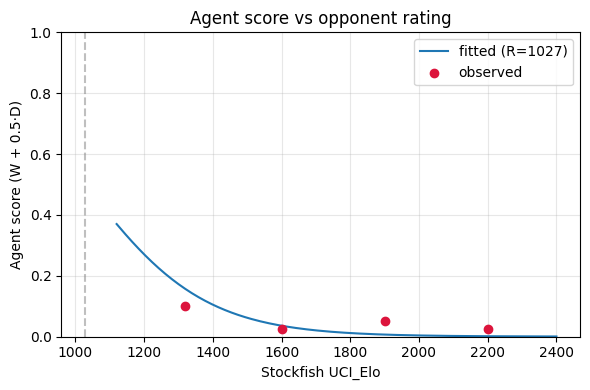

In [ ]:
# --- plot: expected vs observed score curve ------------------------------
# Sanity check that the pooled rating actually fits the data. The curve is
# the theoretical score vs opponent given the fitted rating; dots are the
# measured scores per opponent. Big residuals hint at non-Elo-like behavior
# (e.g. the model handles some opponent styles much better than others).

import numpy as np
import matplotlib.pyplot as plt

opps = np.array([m.opponent_elo for m in results])
scores = np.array([m.score for m in results])
xs = np.linspace(min(opps) - 200, max(opps) + 200, 200)
ys = 1.0 / (1.0 + 10.0 ** ((xs - pooled) / 400.0))

plt.figure(figsize=(6, 4))
plt.plot(xs, ys, label=f"fitted (R={pooled:.0f})")
plt.scatter(opps, scores, color="crimson", zorder=3, label="observed")
plt.axvline(pooled, color="gray", linestyle="--", alpha=0.5)
plt.xlabel("Stockfish UCI_Elo")
plt.ylabel("Agent score (W + 0.5·D)")
plt.ylim(0, 1)
plt.legend()
plt.title("Agent score vs opponent rating")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()